## Benchmarking Predictions

In this section, we benchmark the model's performance on synthetic data of varying sequence lengths. Specifically, we'll measure:
1. Inference time
2. Allocated RAM during inference

Finally, we'll plot the results to visualize how sequence length affects inference time and RAM usage.


In [1]:
from methyldl.modelling.dnabert2 import EpigenDnabert2
from methyldl.modelling.dismir import Dismir
from methyldl.data.dataset import SupervisedDataset, generate_example_data, generate_example_data_for_methylbert
import os
import torch
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
from methyldl.modelling.utils import count_model_parameters
from methyldl.modelling.methylbert import MethylVocab,MethylBertFinetuneDataset, MethylBert, default_methylbert_config

x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pickle
with open("performance_data.pkl", "rb") as f:
    inference_times, allocated_ram = pickle.load(f)

In [ ]:
# Benchmarking variables
import numpy as np
sequence_lengths = [2**i for i in range(16) if i >5] # [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
n_repeats = 100
#models = ["DISMIR", "DNABERT2", "MethylBERT"]
models = ["DISMIR_MINIGRU", "DISMIR"]
# inference_times = {model: {seq_len: [] for seq_len in sequence_lengths} for model in models}
# allocated_ram = {model: {seq_len: [] for seq_len in sequence_lengths} for model in models}
inference_times["DISMIR_MINIGRU"] = {seq_len: [] for seq_len in sequence_lengths}
allocated_ram["DISMIR_MINIGRU"] = {seq_len: [] for seq_len in sequence_lengths}
inference_times["DISMIR"] = {seq_len: [] for seq_len in sequence_lengths}
allocated_ram["DISMIR"] = {seq_len: [] for seq_len in sequence_lengths}
from IPython.utils import io


for seq_len in tqdm(sequence_lengths, f"Processing {n_repeats} sequences each of length {sequence_lengths}"):
    for model in models:
        try:
            if model == "DNABERT2":
                predictor = EpigenDnabert2(max_sequence_length=seq_len)
            elif model == "DISMIR":
                predictor = Dismir(seq_len, "", "", "")
            elif model == "DISMIR_MINIGRU":
                predictor = Dismir(seq_len, "", "", "", flavour="minigru")
            elif model == "MethylBERT":
                methyl_samples_seq_len = len(generate_example_data_for_methylbert(
                    sequence_length=seq_len,
                    include_cpg_methylation=True,
                    include_m6a_methylation=False,
                    include_labels=True,
                    num_samples=1  
                )[1][1])
                predictor = MethylBert(custom_config=default_methylbert_config, 
                            foundation_model_path = "hanyangii/methylbert_hg19_6l",
                            num_labels=2,
                            num_dmr_labels = 100,
                            seq_len=methyl_samples_seq_len) 
                
            else:
                raise ValueError(f"Unexpected model: {model}")

            print(f"Predictor successfully initialized for {model}")
            print(f"Running simulation for {model}. Sequence Length: {seq_len}. Number of parameters: {count_model_parameters(predictor.model)}")

            for i in range(n_repeats):


                # Generate synthetic data for the given sequence length
                if model == "MethylBERT":
                    synthetic_data = generate_example_data_for_methylbert(
                        sequence_length=seq_len,
                        include_cpg_methylation=True,
                        include_m6a_methylation=True,
                        include_labels=False,
                        num_samples=1  # Single sample per repeat
                    )
                    with io.capture_output() as captured:
                        synthetic_dataset = MethylBertFinetuneDataset(
                            data_source = synthetic_data,
                            vocab=MethylVocab(k=3),
                            seq_len=methyl_samples_seq_len
              )
                else:
                    synthetic_data = generate_example_data(
                        sequence_length=seq_len,
                        include_cpg_methylation=True,
                        include_m6a_methylation=True,
                        include_labels=False,
                        num_samples=1  # Single sample per repeat
                    )

                # Measure inference time and allocated RAM
                start_time = time.time()
                torch.cuda.reset_peak_memory_stats()  # Reset RAM tracking if using GPU
                with io.capture_output() as captured:
                    if model == "DNABERT2":
                        synthetic_dataset = SupervisedDataset(
                            tokenizer=predictor.tokenizer,
                            data_path_or_list=synthetic_data,
                            kmer=-1
                        )
                        predictor.predict(synthetic_dataset)
                    elif model in ["DISMIR","DISMIR_MINIGRU"]:
                        dna, c_methylation = synthetic_data[1][0], synthetic_data[1][1]
                        if i>1 and seq_len > 10000 and model == "DISMIR":
                            continue
                        if i>1 and seq_len > 20000 and model == "DISMIR_MINIGRU":
                            continue
                        predictor.predict([dna], [c_methylation], batch_size=1)
                    elif model == "MethylBERT":
                        predictor.predict(synthetic_dataset)


                elapsed_time = time.time() - start_time
                peak_ram = torch.cuda.max_memory_allocated() / (1024 ** 2)  # RAM in MB

                inference_times[model][seq_len].append(elapsed_time)
                allocated_ram[model][seq_len].append(peak_ram)

            del predictor  # Delete the model after all runs
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"Error initializing predictor for model {model} with sequence length {seq_len}: {e}")

### Visualizing Benchmark Results

Finally, we'll plot:
1. **Sequence Length vs Inference Time**
2. **Sequence Length vs Allocated RAM**

These plots help us understand the performance characteristics of EpigenDnabert2.

In [4]:
import pickle
data_tuple = (inference_times, allocated_ram)
with open("performance_data.pkl", "wb") as f:
    pickle.dump(data_tuple, f)

In [ ]:
list(inference_times.keys())[0,3,2,1]

TypeError: list indices must be integers or slices, not list

In [17]:
models[0,3,2,1]

NameError: name 'models' is not defined

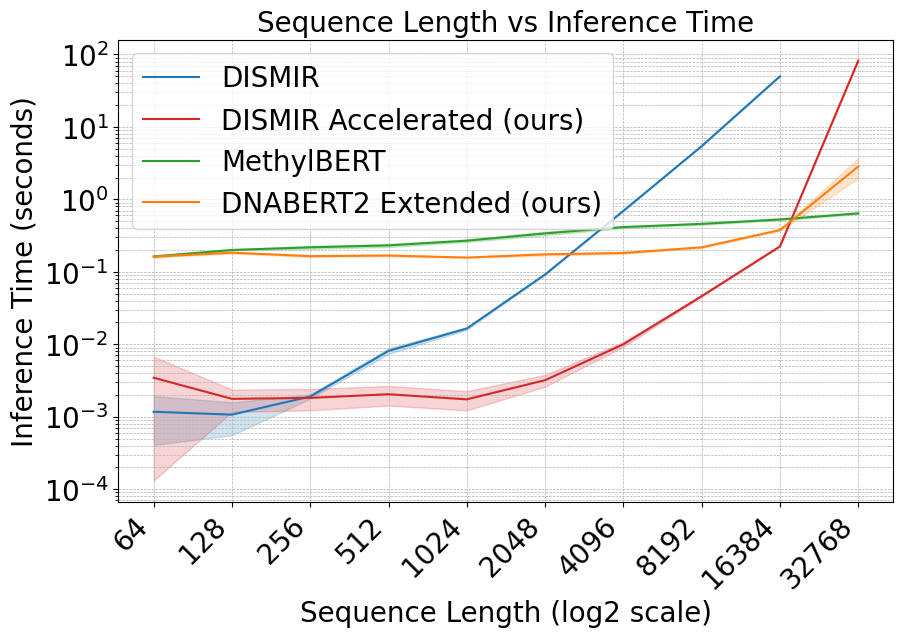

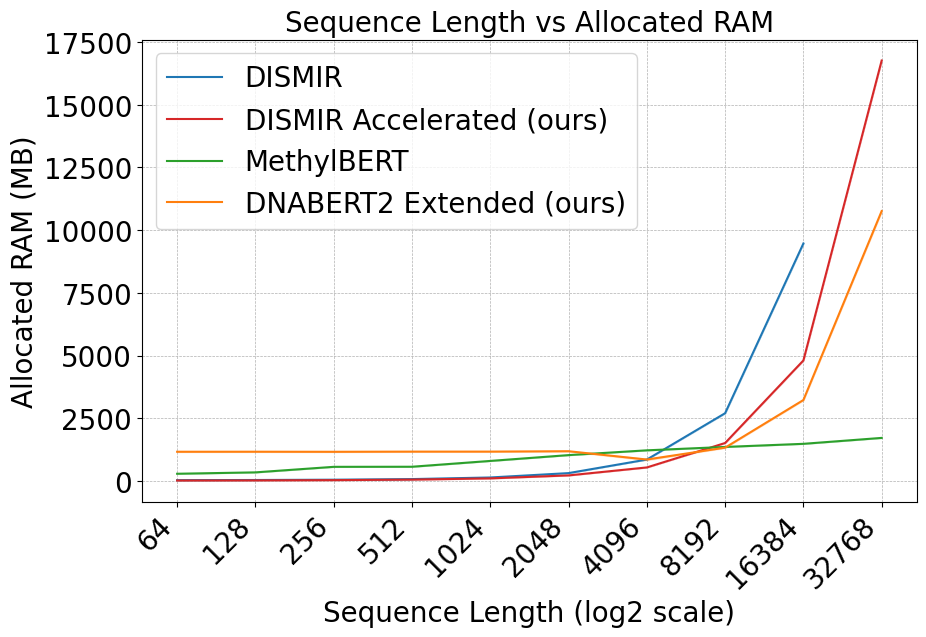

In [21]:
import numpy as np
import matplotlib.pyplot as plt

sequence_lengths = [2**i for i in range(16) if i >5]

def plot_benchmark_results(inference_times, allocated_ram, sequence_lengths, log_scale=True):
    """
    Plots inference time and allocated RAM as line plots with shaded 95% confidence intervals.
    
    Parameters:
        inference_times (dict): Dictionary with inference times for each model and sequence length.
        allocated_ram (dict): Dictionary with allocated RAM for each model and sequence length.
        sequence_lengths (list): List of sequence lengths tested.
        log_scale (bool): Whether to use a log scale for the y-axis.
    """
    models = list(inference_times.keys())
    models = [models[i] for i in [0,3,2,1]]
    colors = plt.cm.tab10(range(len(models)))  # Assign distinct colors to models


    # Convert sequence lengths to log2 scale for x-axis
    log_seq_lengths = np.log2(sequence_lengths)

    # --- Inference Time Plot ---
    models_labels = ["DISMIR", "DNABERT2 Extended (ours)", "MethylBERT", "DISMIR Accelerated (ours)"]

    # Function to compute mean and confidence interval
    def mean_and_confidence(data_list):
        means = [np.mean(seq) if len(seq) > 0 else np.nan for seq in data_list]
        std_errs = [np.std(seq) / np.sqrt(len(seq)) if len(seq) > 1 else np.nan for seq in data_list]
        conf_intervals = [1.96 * se if not np.isnan(se) else np.nan for se in std_errs]
        return np.array(means), np.array(conf_intervals)

    plt.figure(figsize=(10, 6))
    for model, i in zip(models, [0,3,2,1]):
        data_list = [inference_times[model][seq_len] for seq_len in sequence_lengths]
        
        if any(len(d) > 0 for d in data_list):  # Ensure there's valid data
            mean, conf = mean_and_confidence(data_list)

            plt.plot(log_seq_lengths, mean, label=models_labels[i], color=colors[i])
            plt.fill_between(log_seq_lengths, mean - conf, mean + conf, color=colors[i], alpha=0.2)

    plt.xlabel("Sequence Length (log2 scale)", fontsize=20)
    plt.ylabel("Inference Time (seconds)", fontsize=20)
    plt.title("Sequence Length vs Inference Time", fontsize=20)
    plt.xticks(log_seq_lengths, sequence_lengths, rotation=45, ha='right', fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    
    if log_scale:
        plt.yscale("log")

    plt.legend(loc="upper left", fontsize=20)
    plt.show()

    # --- Allocated RAM Plot ---
    plt.figure(figsize=(10, 6))
    for model, i in zip(models, [0,3,2,1]):
            data_list = [allocated_ram[model][seq_len] for seq_len in sequence_lengths]
            
            if any(len(d) > 0 for d in data_list):  # Ensure there's valid data
                mean, conf = mean_and_confidence(data_list)

                plt.plot(log_seq_lengths, mean, label=models_labels[i], color=colors[i])
                plt.fill_between(log_seq_lengths, mean - conf, mean + conf, color=colors[i], alpha=0.2)

    plt.xlabel("Sequence Length (log2 scale)", fontsize=20)
    plt.ylabel("Allocated RAM (MB)", fontsize=20)
    plt.title("Sequence Length vs Allocated RAM", fontsize=20)
    plt.xticks(log_seq_lengths, sequence_lengths, rotation=45, ha='right', fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(which="both", linestyle="--", linewidth=0.5)
    
    # if log_scale:
    #     plt.yscale("log")

    plt.legend(loc="upper left", fontsize=20)
    plt.show()

# Example usage:
plot_benchmark_results(inference_times, allocated_ram, sequence_lengths, log_scale=True)


### Running Pytroch Profiler

In [ ]:
sequence_lengths = [2**i for i in range(16) if i >5]

In [ ]:
from torch.profiler import profile, record_function, ProfilerActivity

In [ ]:
if torch.cuda.is_available():
    device = 'cuda'
seq_len = sequence_lengths[-1]
synthetic_data = generate_example_data(
                        sequence_length=seq_len,
                        include_cpg_methylation=True,
                        include_m6a_methylation=True,
                        include_labels=False,
                        num_samples=1  # Single sample per repeat
                    )
predictor = Dismir(seq_len, "", "", "", flavour="minigru")
dna, c_methylation = synthetic_data[1][0], synthetic_data[1][1]
predictor.model = predictor.model.to(device)


In [ ]:
predictor.predict([dna], [c_methylation], batch_size=1)

In [ ]:
sort_by_keyword = device + "_time_total"

In [ ]:
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True,profile_memory=True) as prof:
    with record_function("model_inference"):
        predictor.predict([dna], [c_methylation], batch_size=1)

In [ ]:
prof.key_averages().total_average().cpu_time
prof.key_averages().total_average().device_memory_usage  //1024**2

In [ ]:
prof.key_averages().total_average()

In [ ]:
print(prof.key_averages().table(row_limit=100))